<a href="https://colab.research.google.com/github/IvanLuetic/racunalni-vid/blob/main/RacunalniVid.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Ćelije 1, 2, 3, 6 i 7 samo jednom pokrećemo da bi spremili podatke na Google Drive





In [ ]:
!pip install -q --upgrade kaggle

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.2/126.2 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 262.5/262.5 kB 8.7 MB/s eta 0:00:00


In [ ]:
import os
os.makedirs('/root/.kaggle', exist_ok=True)

with open('/root/.kaggle/access_token', 'w') as f:
    f.write('')

!chmod 600 /root/.kaggle/access_token

In [ ]:
!kaggle datasets download -d benjaminkz/places365 -p /content/places365_raw --unzip

Dataset URL: https://www.kaggle.com/datasets/benjaminkz/places365
License(s): CC0-1.0
100% 23.5G/23.5G [04:47<00:00, 88.0MB/s]



In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import shutil, os
shutil.unpack_archive('/content/drive/MyDrive/places365_subset.zip', '/content/places365_subset')
print( len(os.listdir('/content/places365_subset/train')), 'classes')

15 classes


In [ ]:
import os, shutil, random

SRC_TRAIN = '/content/places365_raw/train'
SRC_VAL = '/content/places365_raw/val'
DST = '/content/places365_subset'
N_TRAIN, N_VAL = 300, 60

selected_classes = [
    'beach', 'forest-broadleaf', 'kitchen', 'bedroom',
    'stadium-baseball', 'mountain', 'office', 'street',
    'bridge', 'desert-sand', 'restaurant_patio', 'sky',
    'raceway', 'boardwalk', 'islet'
]

random.seed(42)

for cls in selected_classes:
    train_src_folder = f'{SRC_TRAIN}/{cls}'
    train_imgs = os.listdir(train_src_folder)
    random.shuffle(train_imgs)
    train_dst_folder = f'{DST}/train/{cls}'
    os.makedirs(train_dst_folder, exist_ok=True)
    for f in train_imgs[:N_TRAIN]:
        shutil.copy(f'{train_src_folder}/{f}', f'{train_dst_folder}/{f}')

    val_src_folder = f'{SRC_VAL}/{cls}'
    val_imgs = os.listdir(val_src_folder)
    random.shuffle(val_imgs)
    val_dst_folder = f'{DST}/val/{cls}'
    os.makedirs(val_dst_folder, exist_ok=True)
    for f in val_imgs[:N_VAL]:
        shutil.copy(f'{val_src_folder}/{f}', f'{val_dst_folder}/{f}')

    print(f'{cls}: {len(os.listdir(train_dst_folder))} train, {len(os.listdir(val_dst_folder))} val')



In [ ]:
import shutil

shutil.make_archive('/content/places365_subset', 'zip', '/content/places365_subset')
shutil.copy('/content/places365_subset.zip', '/content/drive/MyDrive/places365_subset.zip')
print('Saved to Drive.')

In [ ]:
import os, random
import numpy as np
import torch

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

CONFIG = {
    'data_root': '/content/places365_subset',
    'batch_size': 32,
    'num_epochs': 15,
    'learning_rate': 1e-3,
    'pretrained_learning_rate': 1e-4,
    'weight_decay': 1e-4,
    'img_size': 224,
    'num_workers': 2,
    'save_dir': '/content/drive/MyDrive/places365_results',
}

os.makedirs(CONFIG['save_dir'], exist_ok=True)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device)
print('Seed:', SEED)

Device: cuda
Seed: 42


In [ ]:
from torchvision import transforms

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

train_transform = transforms.Compose([
    transforms.RandomResizedCrop(CONFIG['img_size'], scale=(0.8, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

val_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(CONFIG['img_size']),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

In [ ]:
from torchvision import datasets

train_dir = os.path.join(CONFIG['data_root'], 'train')
val_dir = os.path.join(CONFIG['data_root'], 'val')

train_dataset = datasets.ImageFolder(
    train_dir,
    transform=train_transform,
)
val_full_dataset = datasets.ImageFolder(
    val_dir,
    transform=val_transform,
)

class_names = train_dataset.classes
num_classes = len(class_names)
assert val_full_dataset.classes == class_names

val_targets = np.array(val_full_dataset.targets)
split_rng = np.random.default_rng(SEED)
val_indices, test_indices = [], []

for class_idx in range(num_classes):
    class_indices = np.where(val_targets == class_idx)[0]
    split_rng.shuffle(class_indices)
    midpoint = len(class_indices) // 2
    val_indices.extend(class_indices[:midpoint])
    test_indices.extend(class_indices[midpoint:])

val_dataset = torch.utils.data.Subset(val_full_dataset, val_indices)
test_dataset = torch.utils.data.Subset(val_full_dataset, test_indices)

print(f'Broj klasa: {num_classes}')
print(f'Train uzoraka: {len(train_dataset)}')
print(f'Validation uzoraka: {len(val_dataset)}')
print(f'Test uzoraka: {len(test_dataset)}')

Broj klasa: 15
Train uzoraka: 4500
Validation uzoraka: 450
Test uzoraka: 450


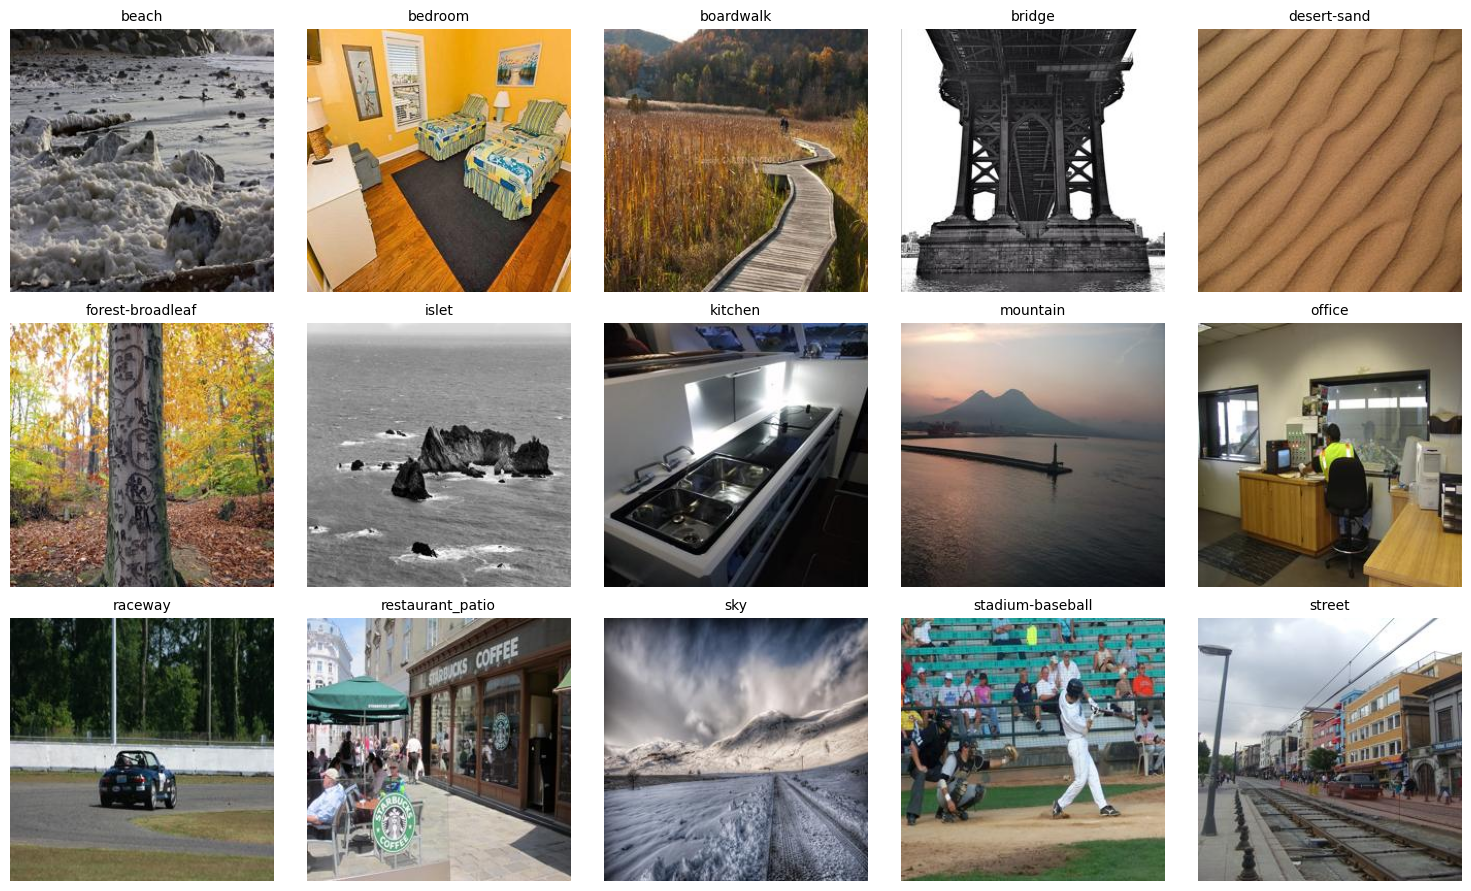

In [ ]:
import matplotlib.pyplot as plt
from PIL import Image
import os

fig, axes = plt.subplots(3, 5, figsize=(15, 9))
axes = axes.flatten()

for ax, cls in zip(axes, class_names):
    folder = os.path.join(CONFIG['data_root'], 'train', cls)
    img_path = os.path.join(folder, sorted(os.listdir(folder))[0])
    img = Image.open(img_path)
    ax.imshow(img)
    ax.set_title(cls, fontsize=10)
    ax.axis('off')

plt.tight_layout()
plt.show()

In [ ]:
from torch.utils.data import DataLoader

def seed_worker(worker_id):
    worker_seed = torch.initial_seed() % (2**32)
    np.random.seed(worker_seed)
    random.seed(worker_seed)

loader_generator = torch.Generator()
loader_generator.manual_seed(SEED)

loader_kwargs = {
    'batch_size': CONFIG['batch_size'],
    'num_workers': CONFIG['num_workers'],
    'pin_memory': torch.cuda.is_available(),
    'worker_init_fn': seed_worker,
    'persistent_workers': CONFIG['num_workers'] > 0,
}

train_loader = DataLoader(
    train_dataset,
    shuffle=True,
    generator=loader_generator,
    **loader_kwargs,
)

val_loader = DataLoader(
    val_dataset,
    shuffle=False,
    **loader_kwargs,
)

test_loader = DataLoader(
    test_dataset,
    shuffle=False,
    **loader_kwargs,
)

In [ ]:
import torch.nn as nn

class ConvBlock(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),
        )

    def forward(self, x):
        return self.block(x)


class CustomCNN(nn.Module):
    def __init__(self, num_classes, in_channels=3):
        super().__init__()
        self.features = nn.Sequential(
            ConvBlock(in_channels, 32),
            ConvBlock(32, 64),
            ConvBlock(64, 128),
            ConvBlock(128, 256),
        )
        self.pool = nn.AdaptiveAvgPool2d(1)
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(0.4),
            nn.Linear(256, 128),
            nn.ReLU(inplace=True),
            nn.Dropout(0.3),
            nn.Linear(128, num_classes),
        )

    def forward(self, x):
        x = self.features(x)
        x = self.pool(x)
        return self.classifier(x)

In [ ]:
import torch.optim as optim
from tqdm import tqdm

def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()

    if getattr(model, '_backbone_frozen', False):
        if hasattr(model, 'features'):
            model.features.eval()
        elif hasattr(model, 'fc'):
            for name, module in model.named_children():
                if name != 'fc':
                    module.eval()

    running_loss = 0.0
    correct = 0
    total = 0
    pbar = tqdm(loader, desc='Train', leave=False)

    for images, labels in pbar:
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)
        optimizer.zero_grad(set_to_none=True)
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        preds = outputs.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)
        pbar.set_postfix({'loss': f'{loss.item():.4f}'})

    return running_loss / total, correct / total

@torch.inference_mode()
def evaluate(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    all_preds, all_labels = [], []

    for images, labels in tqdm(loader, desc='Val', leave=False):
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)
        outputs = model(images)
        loss = criterion(outputs, labels)

        running_loss += loss.item() * images.size(0)
        preds = outputs.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

    return running_loss / total, correct / total, all_preds, all_labels

In [ ]:
import copy
import json

def train_model(
    model,
    model_name,
    train_loader,
    val_loader,
    device,
    num_epochs=CONFIG['num_epochs'],
    lr=CONFIG['learning_rate'],
    weight_decay=CONFIG['weight_decay'],
):
    model = model.to(device)
    criterion = nn.CrossEntropyLoss()
    trainable_params = [p for p in model.parameters() if p.requires_grad]
    optimizer = optim.AdamW(trainable_params, lr=lr, weight_decay=weight_decay)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_epochs)

    ckpt_path = os.path.join(CONFIG['save_dir'], f'{model_name}_checkpoint.pth')
    best_path = os.path.join(CONFIG['save_dir'], f'{model_name}_best.pth')
    hist_path = os.path.join(CONFIG['save_dir'], f'{model_name}_history.json')

    experiment_config = {
        'model_name': model_name,
        'architecture': model.__class__.__name__,
        'backbone_frozen': bool(getattr(model, '_backbone_frozen', False)),
        'num_epochs': int(num_epochs),
        'learning_rate': float(lr),
        'weight_decay': float(weight_decay),
        'seed': int(SEED),
        'train_samples': len(train_loader.dataset),
        'validation_samples': len(val_loader.dataset),
    }

    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
    best_acc = -1.0
    best_state = None
    start_epoch = 0

    if os.path.exists(ckpt_path):
        ckpt = torch.load(ckpt_path, map_location=device)
        if ckpt.get('config') == experiment_config:
            model.load_state_dict(ckpt['model_state_dict'])
            optimizer.load_state_dict(ckpt['optimizer_state_dict'])
            scheduler.load_state_dict(ckpt['scheduler_state_dict'])
            history = ckpt['history']
            best_acc = ckpt['best_acc']
            best_state = ckpt.get('best_state')
            start_epoch = ckpt['epoch'] + 1
            print(f'[{model_name}] Resuming from epoch {start_epoch}/{num_epochs}')
        else:
            print(f'[{model_name}] Ignoring incompatible checkpoint and starting fresh')

    for epoch in range(start_epoch, num_epochs):
        train_loss, train_acc = train_one_epoch(
            model, train_loader, criterion, optimizer, device
        )
        val_loss, val_acc, _, _ = evaluate(
            model, val_loader, criterion, device
        )
        scheduler.step()

        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['train_acc'].append(train_acc)
        history['val_acc'].append(val_acc)

        print(
            f'[{model_name}] Epoch {epoch + 1}/{num_epochs} '
            f'train_loss={train_loss:.4f} train_acc={train_acc:.4f} '
            f'val_loss={val_loss:.4f} val_acc={val_acc:.4f}'
        )

        if val_acc > best_acc:
            best_acc = val_acc
            best_state = copy.deepcopy(model.state_dict())

        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'scheduler_state_dict': scheduler.state_dict(),
            'history': history,
            'best_acc': best_acc,
            'best_state': best_state,
            'config': experiment_config,
        }, ckpt_path)

    if best_state is None:
        best_state = copy.deepcopy(model.state_dict())
        best_acc = max(history['val_acc']) if history['val_acc'] else 0.0

    model.load_state_dict(best_state)
    torch.save({
        'model_state_dict': best_state,
        'val_acc': best_acc,
        'config': experiment_config,
    }, best_path)

    with open(hist_path, 'w') as f:
        json.dump(history, f)

    return model, history

In [ ]:
custom_model = CustomCNN(num_classes=num_classes)
custom_model, custom_history = train_model(custom_model, 'custom_cnn', train_loader, val_loader, device)

[custom_cnn] Resuming from epoch 15/15


In [ ]:
print('Best val accuracy:', max(custom_history['val_acc']))
print('\nFull history:')
for i, (tl, ta, vl, va) in enumerate(zip(
        custom_history['train_loss'], custom_history['train_acc'],
        custom_history['val_loss'], custom_history['val_acc'])):
    print(f"Epoch {i+1}: train_loss={tl:.4f} train_acc={ta:.4f} val_loss={vl:.4f} val_acc={va:.4f}")

Best val accuracy: 0.5711111111111111

Full history:
Epoch 1: train_loss=2.3000 train_acc=0.2153 val_loss=2.2238 val_acc=0.2578
Epoch 2: train_loss=2.0245 train_acc=0.3047 val_loss=1.8938 val_acc=0.3511
Epoch 3: train_loss=1.8878 train_acc=0.3398 val_loss=1.6607 val_acc=0.4244
Epoch 4: train_loss=1.8217 train_acc=0.3764 val_loss=1.7511 val_acc=0.4111
Epoch 5: train_loss=1.7966 train_acc=0.3804 val_loss=1.6817 val_acc=0.3911
Epoch 6: train_loss=1.7403 train_acc=0.4016 val_loss=1.5917 val_acc=0.4800
Epoch 7: train_loss=1.6739 train_acc=0.4202 val_loss=1.5421 val_acc=0.4756
Epoch 8: train_loss=1.6413 train_acc=0.4269 val_loss=1.4913 val_acc=0.5022
Epoch 9: train_loss=1.6051 train_acc=0.4484 val_loss=1.4826 val_acc=0.5289
Epoch 10: train_loss=1.5767 train_acc=0.4551 val_loss=1.4701 val_acc=0.5133
Epoch 11: train_loss=1.5326 train_acc=0.4729 val_loss=1.3955 val_acc=0.5378
Epoch 12: train_loss=1.4974 train_acc=0.4796 val_loss=1.3649 val_acc=0.5578
Epoch 13: train_loss=1.4987 train_acc=0.4747

In [ ]:
from torchvision import models

def build_pretrained_model(arch, num_classes, freeze_backbone=False):
    if arch == 'vgg16':
        model = models.vgg16(weights=models.VGG16_Weights.IMAGENET1K_V1)
        if freeze_backbone:
            for param in model.features.parameters():
                param.requires_grad = False
        in_features = model.classifier[6].in_features
        model.classifier[6] = nn.Linear(in_features, num_classes)

    elif arch == 'resnet50':
        model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V2)
        if freeze_backbone:
            for name, param in model.named_parameters():
                if not name.startswith('fc'):
                    param.requires_grad = False
        in_features = model.fc.in_features
        model.fc = nn.Linear(in_features, num_classes)

    elif arch == 'efficientnet':
        model = models.efficientnet_b0(
            weights=models.EfficientNet_B0_Weights.IMAGENET1K_V1
        )
        if freeze_backbone:
            for param in model.features.parameters():
                param.requires_grad = False
        in_features = model.classifier[1].in_features
        model.classifier[1] = nn.Linear(in_features, num_classes)

    else:
        raise ValueError(f'Unknown arch: {arch}')

    model._backbone_frozen = freeze_backbone
    return model

In [ ]:
vgg16_model = build_pretrained_model(
    'vgg16',
    num_classes,
    freeze_backbone=True,
)
vgg16_model, vgg16_history = train_model(
    vgg16_model,
    'vgg16_frozen',
    train_loader,
    val_loader,
    device,
    num_epochs=CONFIG['num_epochs'],
    lr=CONFIG['pretrained_learning_rate'],
)

Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /root/.cache/torch/hub/checkpoints/vgg16-397923af.pth


100%|██████████| 528M/528M [00:04<00:00, 124MB/s]


[vgg16_frozen] Resuming from epoch 15/15


In [ ]:
print('Best val accuracy:', max(vgg16_history['val_acc']) if 'vgg16_history' in dir() else 'not trained yet')

Best val accuracy: 0.8377777777777777


In [ ]:
resnet_model = build_pretrained_model(
    'resnet50',
    num_classes,
    freeze_backbone=True,
)
resnet_model, resnet_history = train_model(
    resnet_model,
    'resnet50_frozen',
    train_loader,
    val_loader,
    device,
    num_epochs=CONFIG['num_epochs'],
    lr=CONFIG['pretrained_learning_rate'],
)

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 116MB/s]


[resnet50_frozen] Resuming from epoch 15/15


In [ ]:
efficientnet_model = build_pretrained_model(
    'efficientnet',
    num_classes,
    freeze_backbone=True,
)
efficientnet_model, efficientnet_history = train_model(
    efficientnet_model,
    'efficientnet_frozen',
    train_loader,
    val_loader,
    device,
    num_epochs=CONFIG['num_epochs'],
    lr=CONFIG['pretrained_learning_rate'],
)

Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 120MB/s] 


[efficientnet_frozen] Resuming from epoch 15/15


In [ ]:
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    confusion_matrix,
    classification_report,
)

def full_evaluation(model, model_name, val_loader, device, class_names):
    criterion = nn.CrossEntropyLoss()
    _, val_acc, preds, labels = evaluate(
        model, val_loader, criterion, device
    )

    acc = accuracy_score(labels, preds)
    balanced_acc = balanced_accuracy_score(labels, preds)
    f1_macro = f1_score(labels, preds, average='macro')
    f1_weighted = f1_score(labels, preds, average='weighted')
    cm = confusion_matrix(labels, preds)

    print(f'--- {model_name} ---')
    print(f'Accuracy: {acc:.4f}')
    print(f'Balanced accuracy: {balanced_acc:.4f}')
    print(f'F1 (macro): {f1_macro:.4f}')
    print(f'F1 (weighted): {f1_weighted:.4f}')
    print(classification_report(
        labels,
        preds,
        target_names=class_names,
        zero_division=0,
    ))

    return {
        'model_name': model_name,
        'accuracy': acc,
        'balanced_accuracy': balanced_acc,
        'f1_macro': f1_macro,
        'f1_weighted': f1_weighted,
        'confusion_matrix': cm,
    }

In [ ]:
models_to_eval = {
    'custom_cnn': custom_model,
    'vgg16': vgg16_model,
    'resnet50': resnet_model,
    'efficientnet': efficientnet_model,
}

results = {}
for name, model in models_to_eval.items():
    results[name] = full_evaluation(
        model,
        name,
        test_loader,
        device,
        class_names,
    )

--- custom_cnn ---
Accuracy: 0.5333
Balanced accuracy: 0.5333
F1 (macro): 0.5207
F1 (weighted): 0.5207
                  precision    recall  f1-score   support

           beach       0.38      0.37      0.37        30
         bedroom       0.50      0.60      0.55        30
       boardwalk       0.35      0.30      0.32        30
          bridge       0.38      0.17      0.23        30
     desert-sand       0.53      0.60      0.56        30
forest-broadleaf       0.59      0.77      0.67        30
           islet       0.41      0.47      0.44        30
         kitchen       0.57      0.70      0.63        30
        mountain       0.44      0.47      0.45        30
          office       0.57      0.27      0.36        30
         raceway       0.68      0.63      0.66        30
restaurant_patio       0.55      0.60      0.57        30
             sky       0.56      0.50      0.53        30
stadium-baseball       0.81      0.83      0.82        30
          street       0.5

--- vgg16 ---
Accuracy: 0.8067
Balanced accuracy: 0.8067
F1 (macro): 0.8039
F1 (weighted): 0.8039
                  precision    recall  f1-score   support

           beach       0.68      0.77      0.72        30
         bedroom       0.97      0.93      0.95        30
       boardwalk       0.63      0.63      0.63        30
          bridge       0.82      0.47      0.60        30
     desert-sand       0.87      0.87      0.87        30
forest-broadleaf       0.87      0.87      0.87        30
           islet       0.81      0.83      0.82        30
         kitchen       0.91      0.97      0.94        30
        mountain       0.66      0.83      0.74        30
          office       0.86      0.83      0.85        30
         raceway       0.81      0.87      0.84        30
restaurant_patio       0.95      0.70      0.81        30
             sky       0.77      0.67      0.71        30
stadium-baseball       0.90      0.93      0.92        30
          street       0.72    

--- resnet50 ---
Accuracy: 0.8089
Balanced accuracy: 0.8089
F1 (macro): 0.8065
F1 (weighted): 0.8065
                  precision    recall  f1-score   support

           beach       0.67      0.67      0.67        30
         bedroom       0.94      1.00      0.97        30
       boardwalk       0.54      0.50      0.52        30
          bridge       0.59      0.53      0.56        30
     desert-sand       0.83      0.80      0.81        30
forest-broadleaf       0.84      0.90      0.87        30
           islet       0.72      0.87      0.79        30
         kitchen       0.97      0.93      0.95        30
        mountain       0.77      0.80      0.79        30
          office       0.93      0.90      0.92        30
         raceway       0.84      0.90      0.87        30
restaurant_patio       0.96      0.87      0.91        30
             sky       0.83      0.63      0.72        30
stadium-baseball       0.88      0.93      0.90        30
          street       0.82 

--- efficientnet ---
Accuracy: 0.7911
Balanced accuracy: 0.7911
F1 (macro): 0.7884
F1 (weighted): 0.7884
                  precision    recall  f1-score   support

           beach       0.68      0.70      0.69        30
         bedroom       0.97      0.93      0.95        30
       boardwalk       0.67      0.53      0.59        30
          bridge       0.61      0.57      0.59        30
     desert-sand       0.85      0.77      0.81        30
forest-broadleaf       0.79      0.90      0.84        30
           islet       0.70      0.87      0.78        30
         kitchen       0.93      0.87      0.90        30
        mountain       0.73      0.80      0.76        30
          office       0.82      0.90      0.86        30
         raceway       0.87      0.87      0.87        30
restaurant_patio       0.79      0.77      0.78        30
             sky       0.82      0.60      0.69        30
stadium-baseball       0.87      0.90      0.89        30
          street       0

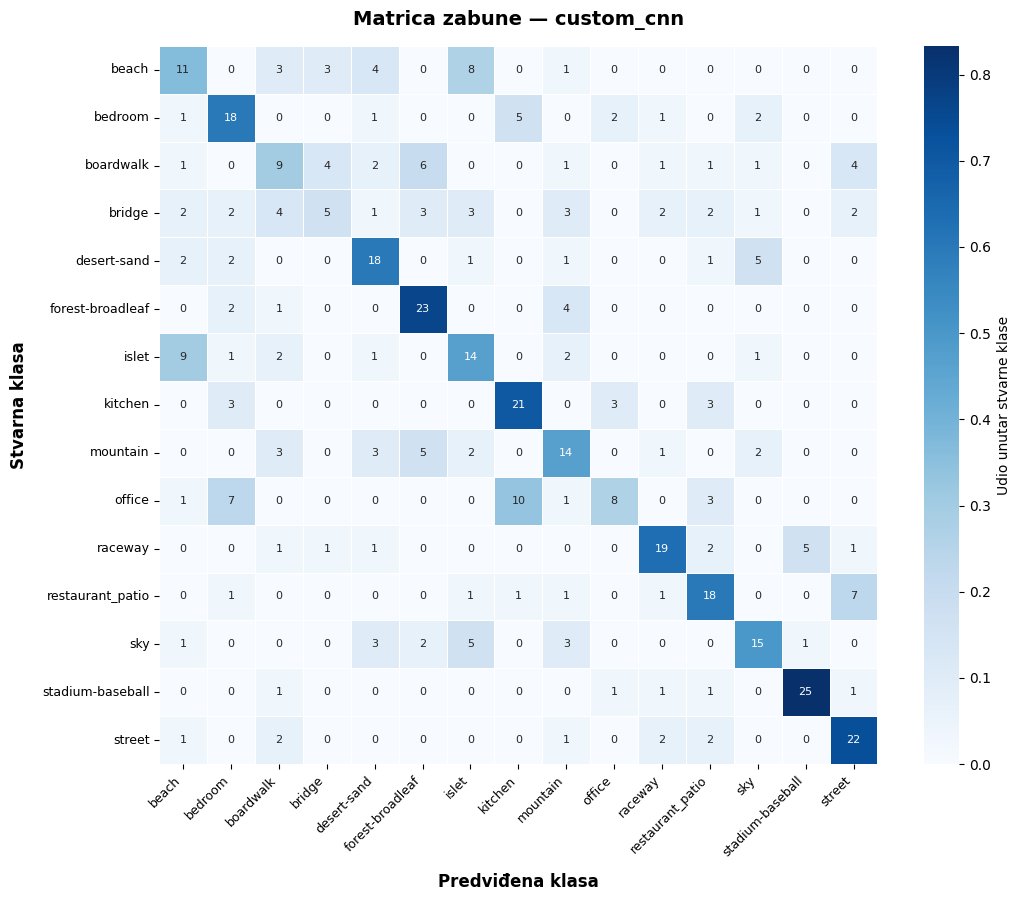

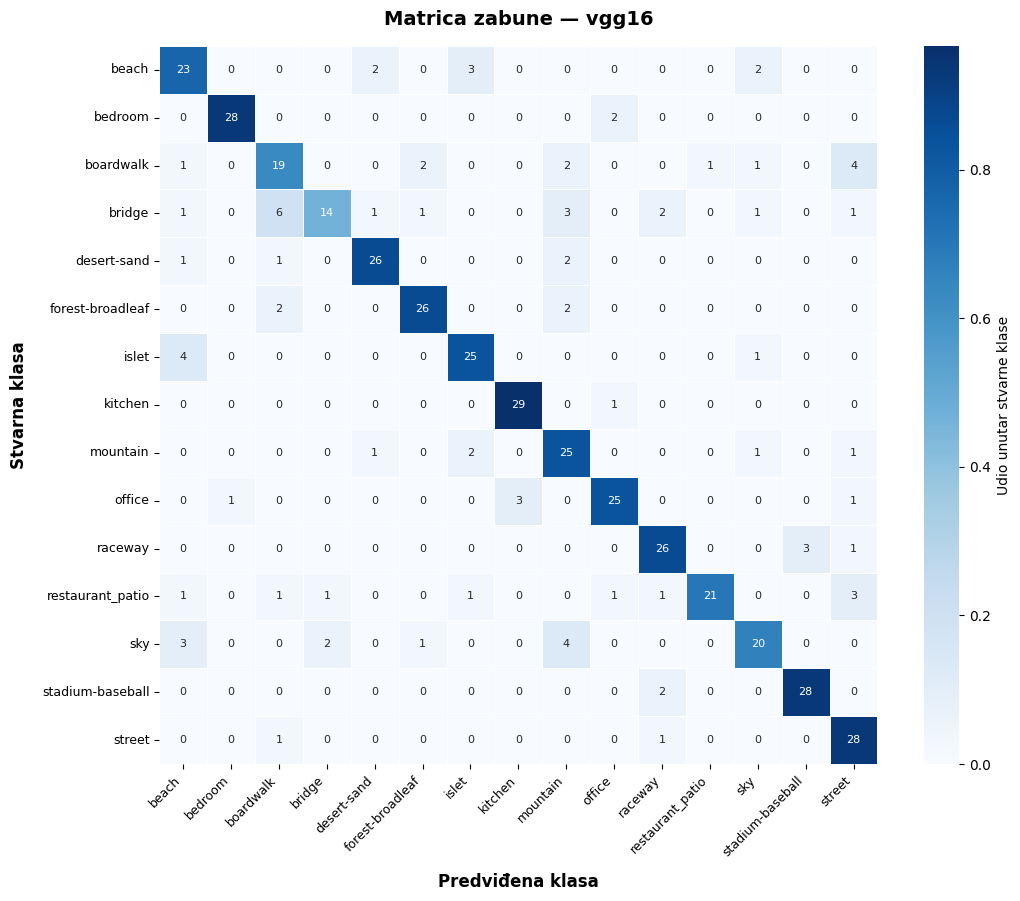

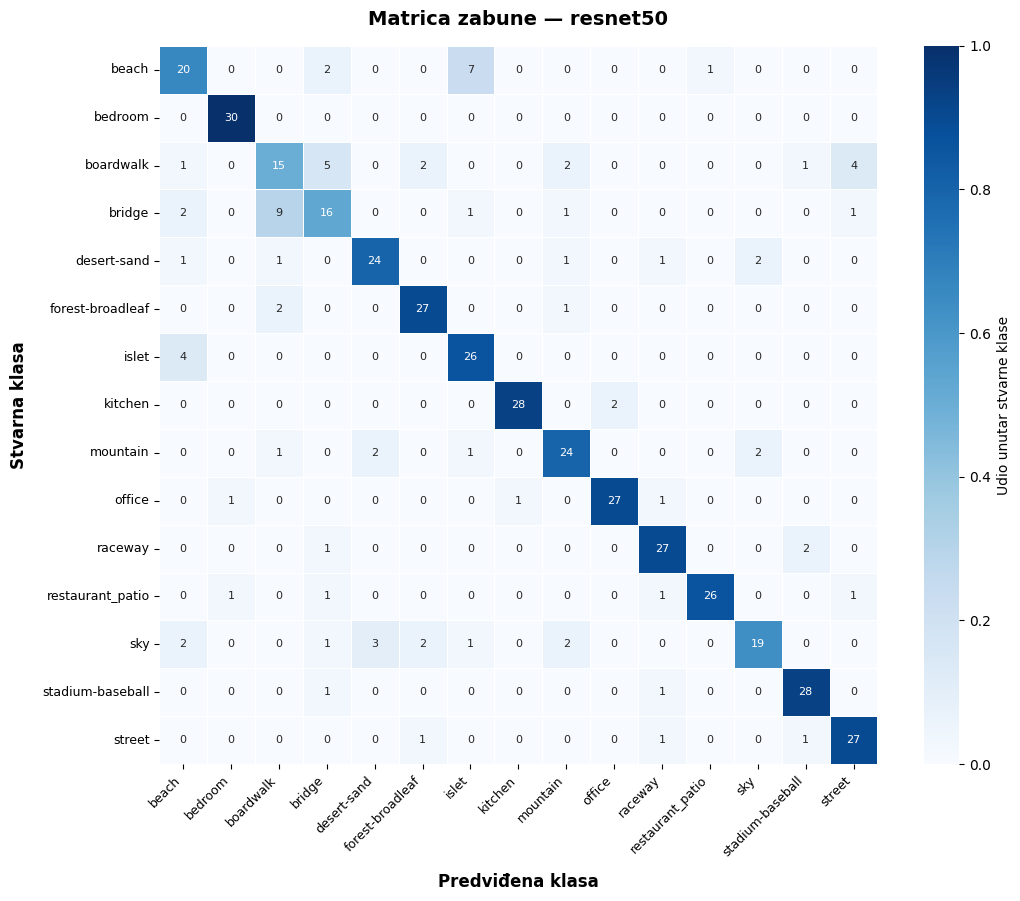

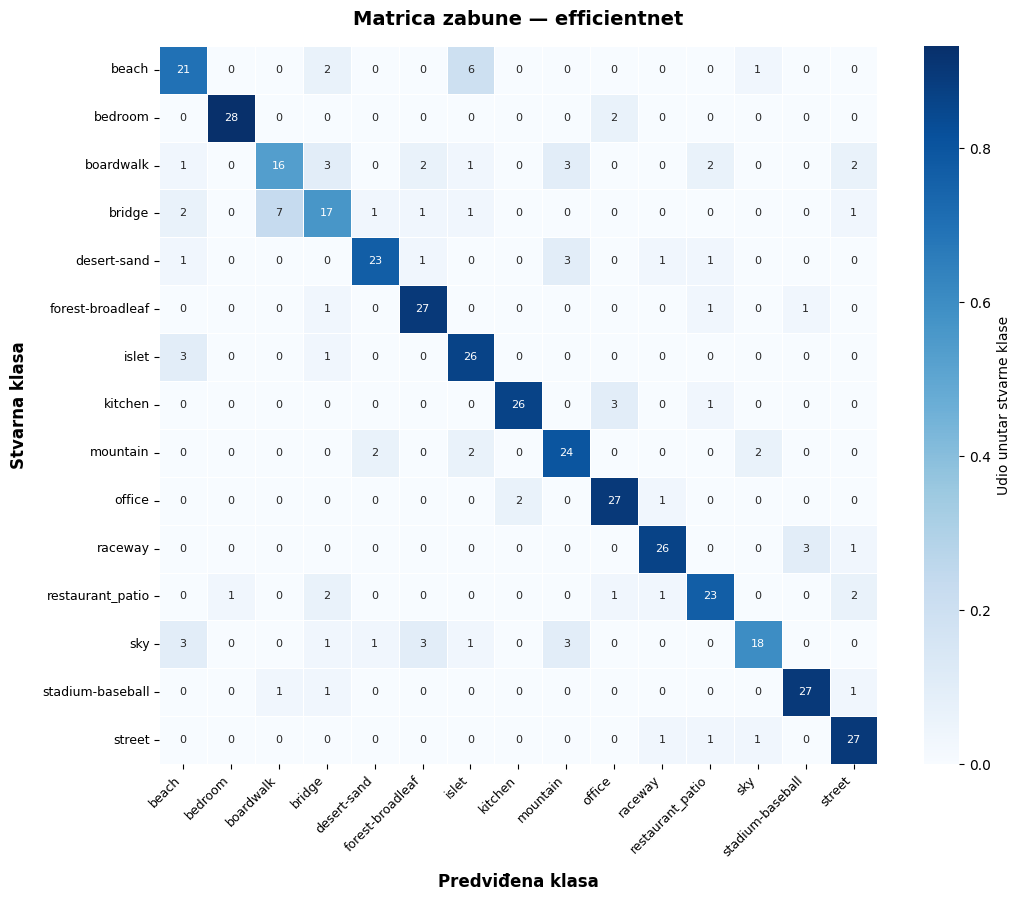

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

def plot_confusion_matrix(cm, class_names, model_name, save_dir):
    cm_norm = cm.astype('float') / cm.sum(axis=1, keepdims=True)

    fig, ax = plt.subplots(figsize=(11, 9))

    sns.heatmap(
        cm_norm,
        annot=cm,
        fmt='d',
        cmap='Blues',
        xticklabels=class_names,
        yticklabels=class_names,
        cbar_kws={'label': 'Udio unutar stvarne klase'},
        linewidths=0.5,
        linecolor='white',
        annot_kws={'size': 8},
        square=True,
        ax=ax
    )

    ax.set_xlabel('Predviđena klasa', fontsize=12, fontweight='bold', labelpad=10)
    ax.set_ylabel('Stvarna klasa', fontsize=12, fontweight='bold', labelpad=10)
    ax.set_title(f'Matrica zabune — {model_name}', fontsize=14, fontweight='bold', pad=15)

    plt.xticks(rotation=45, ha='right', fontsize=9)
    plt.yticks(rotation=0, fontsize=9)

    plt.tight_layout()
    plt.savefig(os.path.join(CONFIG['save_dir'], f'confusion_matrix_{model_name}.png'),
                dpi=200, bbox_inches='tight')
    plt.show()

for name, res in results.items():
    plot_confusion_matrix(res['confusion_matrix'], class_names, name, CONFIG['save_dir'])

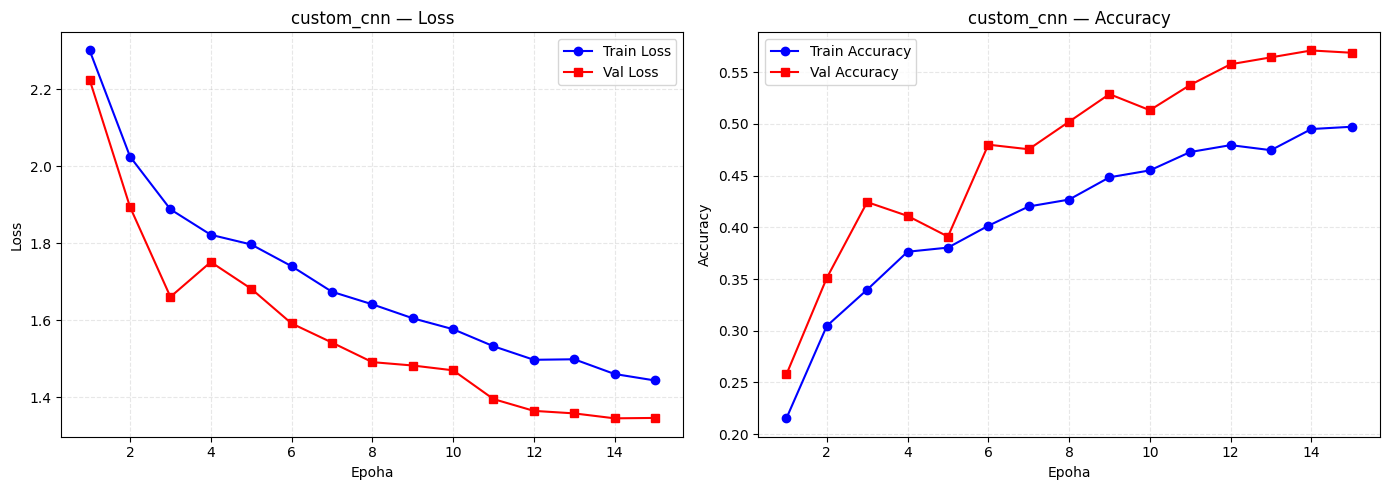

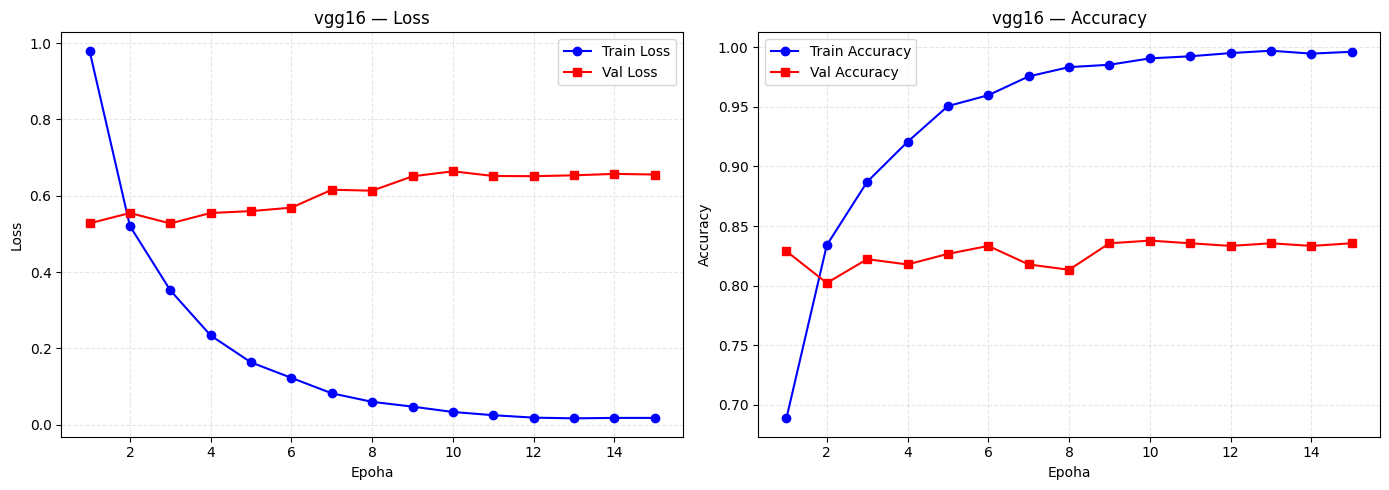

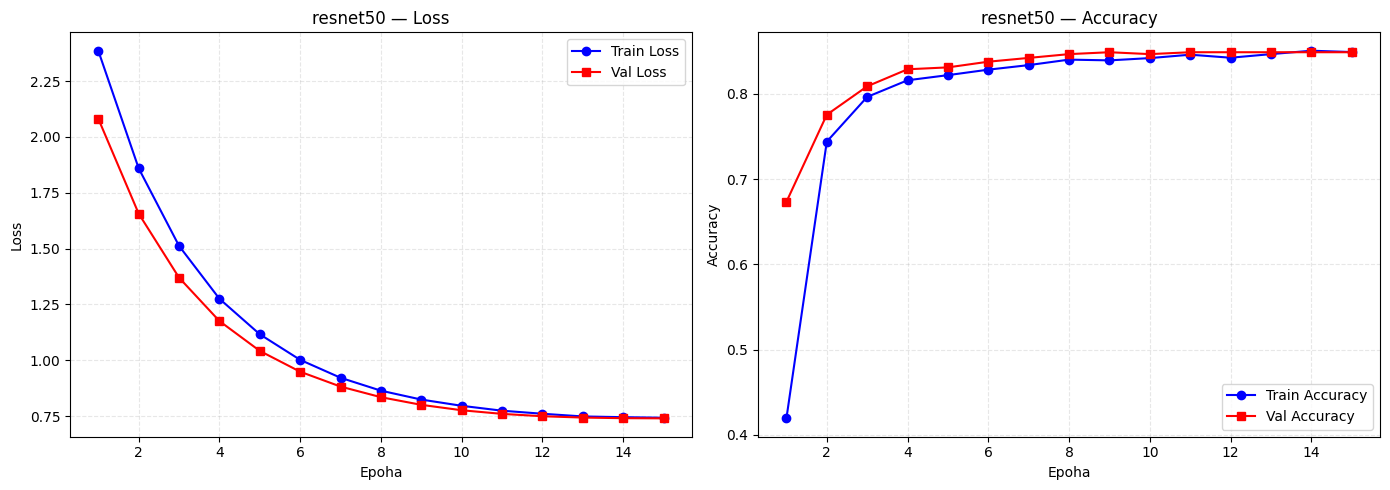

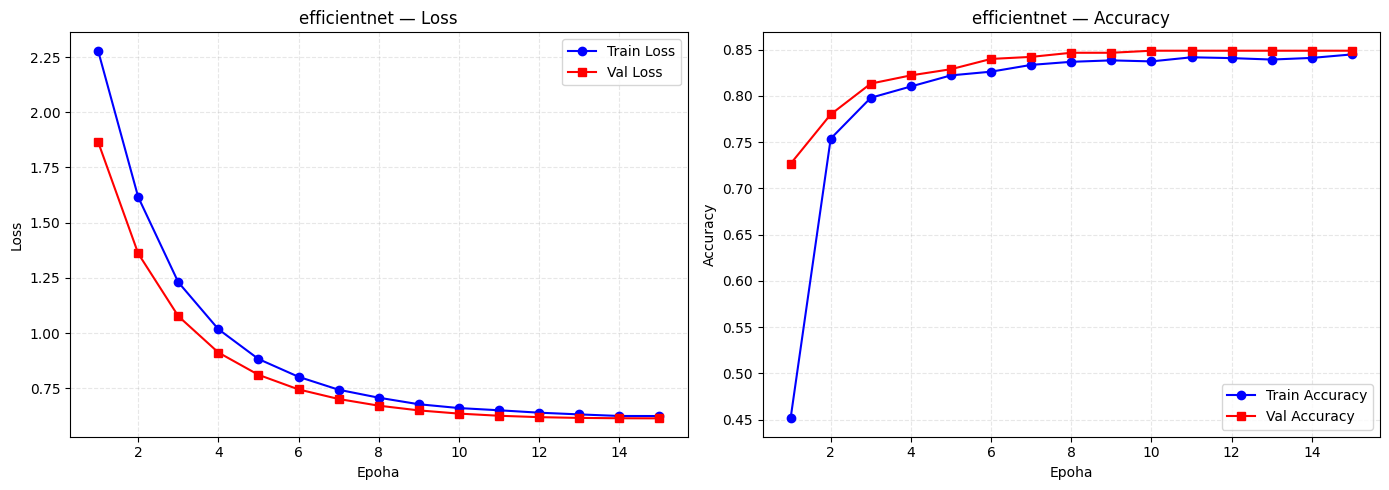

In [ ]:
histories = {
    'custom_cnn': custom_history,
    'vgg16': vgg16_history,
    'resnet50': resnet_history,
    'efficientnet': efficientnet_history,
}

def plot_learning_curves(history, model_name, save_dir):
    epochs = range(1, len(history['train_loss']) + 1)
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    axes[0].plot(epochs, history['train_loss'], 'b-o', label='Train Loss')
    axes[0].plot(epochs, history['val_loss'], 'r-s', label='Val Loss')
    axes[0].set_xlabel('Epoha'); axes[0].set_ylabel('Loss')
    axes[0].set_title(f'{model_name} — Loss'); axes[0].legend(); axes[0].grid(alpha=0.3, linestyle='--')

    axes[1].plot(epochs, history['train_acc'], 'b-o', label='Train Accuracy')
    axes[1].plot(epochs, history['val_acc'], 'r-s', label='Val Accuracy')
    axes[1].set_xlabel('Epoha'); axes[1].set_ylabel('Accuracy')
    axes[1].set_title(f'{model_name} — Accuracy'); axes[1].legend(); axes[1].grid(alpha=0.3, linestyle='--')

    plt.tight_layout()
    plt.savefig(os.path.join(save_dir, f'learning_curves_{model_name}.png'), dpi=200, bbox_inches='tight')
    plt.show()

for name, hist in histories.items():
    plot_learning_curves(hist, name, CONFIG['save_dir'])

,model,accuracy,balanced_accuracy,f1_macro,f1_weighted,best_val_acc_during_training,best_epoch
0,resnet50,0.808889,0.808889,0.806490,0.806490,0.848889,9
1,vgg16,0.806667,0.806667,0.803902,0.803902,0.837778,10
2,efficientnet,0.791111,0.791111,0.788440,0.788440,0.848889,10
3,custom_cnn,0.533333,0.533333,0.520694,0.520694,0.571111,14


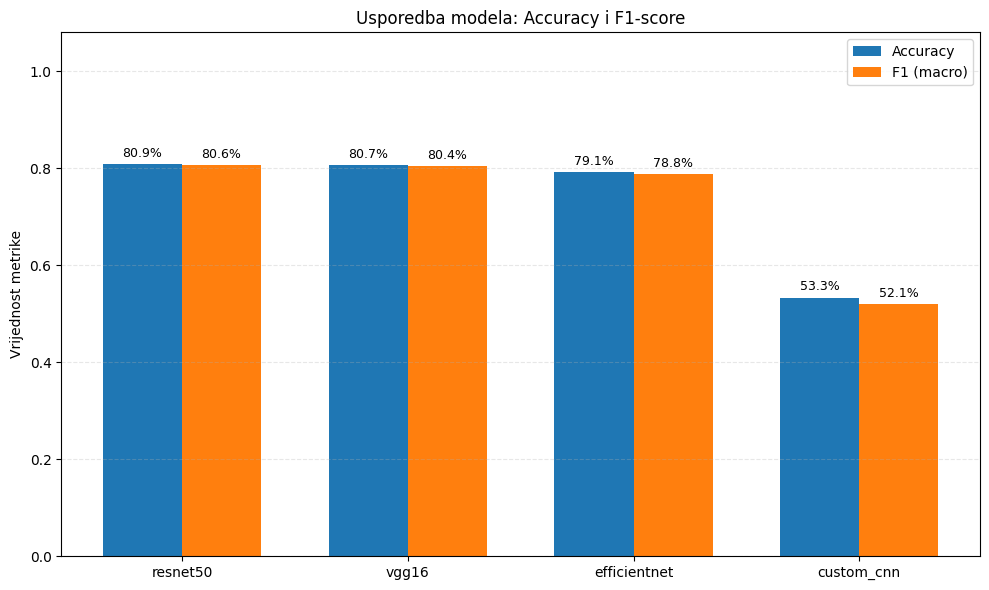

In [ ]:

import numpy as np
import pandas as pd

comparison_rows = []

for name, res in results.items():
    best_epoch = int(np.argmax(histories[name]['val_acc'])) + 1

    comparison_rows.append({
        'model': name,
        'accuracy': res['accuracy'],
        'balanced_accuracy': res['balanced_accuracy'],
        'f1_macro': res['f1_macro'],
        'f1_weighted': res['f1_weighted'],
        'best_val_acc_during_training': max(histories[name]['val_acc']),
        'best_epoch': best_epoch,
    })

comparison_df = (
    pd.DataFrame(comparison_rows)
    .sort_values('accuracy', ascending=False)
    .reset_index(drop=True)
)

display(comparison_df)

x = np.arange(len(comparison_df))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))

accuracy_bars = ax.bar(
    x - width / 2,
    comparison_df['accuracy'],
    width,
    label='Accuracy',
)

f1_bars = ax.bar(
    x + width / 2,
    comparison_df['f1_macro'],
    width,
    label='F1 (macro)',
)

ax.bar_label(
    accuracy_bars,
    labels=[f'{value:.1%}' for value in comparison_df['accuracy']],
    padding=3,
    fontsize=9,
)

ax.bar_label(
    f1_bars,
    labels=[f'{value:.1%}' for value in comparison_df['f1_macro']],
    padding=3,
    fontsize=9,
)

ax.set_xticks(x)
ax.set_xticklabels(comparison_df['model'])
ax.set_ylabel('Vrijednost metrike')
ax.set_title('Usporedba modela: Accuracy i F1-score')
ax.set_ylim(0, 1.08)
ax.legend()
ax.grid(axis='y', alpha=0.3, linestyle='--')

plt.tight_layout()

plt.savefig(
    os.path.join(CONFIG['save_dir'], 'model_comparison.png'),
    dpi=200,
    bbox_inches='tight',
)

plt.show()


In [ ]:
training_summary = []

for name, hist in histories.items():
    best_idx = int(np.argmax(hist['val_acc']))
    training_summary.append({
        'model': name,
        'best_epoch': best_idx + 1,
        'best_val_accuracy': hist['val_acc'][best_idx],
        'final_train_accuracy': hist['train_acc'][-1],
        'final_val_accuracy': hist['val_acc'][-1],
        'final_train_loss': hist['train_loss'][-1],
        'final_val_loss': hist['val_loss'][-1],
    })

training_summary_df = (
    pd.DataFrame(training_summary)
    .sort_values('best_val_accuracy', ascending=False)
    .reset_index(drop=True)
)
display(training_summary_df)

,model,best_epoch,best_val_accuracy,final_train_accuracy,final_val_accuracy,final_train_loss,final_val_loss
0,efficientnet,10,0.848889,0.844889,0.848889,0.623865,0.613406
1,resnet50,9,0.848889,0.849111,0.848889,0.742786,0.740089
2,vgg16,10,0.837778,0.996222,0.835556,0.017657,0.655573
3,custom_cnn,14,0.571111,0.497333,0.568889,1.443715,1.346519


In [ ]:

@torch.inference_mode()
def collect_predictions(model, dataset, loader, device):
    model.eval()
    all_logits = []
    all_labels = []

    for images, labels in loader:
        logits = model(images.to(device, non_blocking=True))
        all_logits.append(logits.cpu())
        all_labels.append(labels.cpu())

    logits = torch.cat(all_logits)
    labels = torch.cat(all_labels)
    probabilities = torch.softmax(logits, dim=1)
    confidences, predictions = probabilities.max(dim=1)

    if hasattr(dataset, 'indices'):
        sample_indices = np.asarray(dataset.indices)
    else:
        sample_indices = np.arange(len(dataset))

    return {
        'logits': logits.numpy(),
        'probabilities': probabilities.numpy(),
        'labels': labels.numpy(),
        'predictions': predictions.numpy(),
        'confidences': confidences.numpy(),
        'sample_indices': sample_indices,
    }

prediction_cache = {
    name: collect_predictions(model, test_dataset, test_loader, device)
    for name, model in models_to_eval.items()
}

print('Collected test predictions')

Collected test predictions


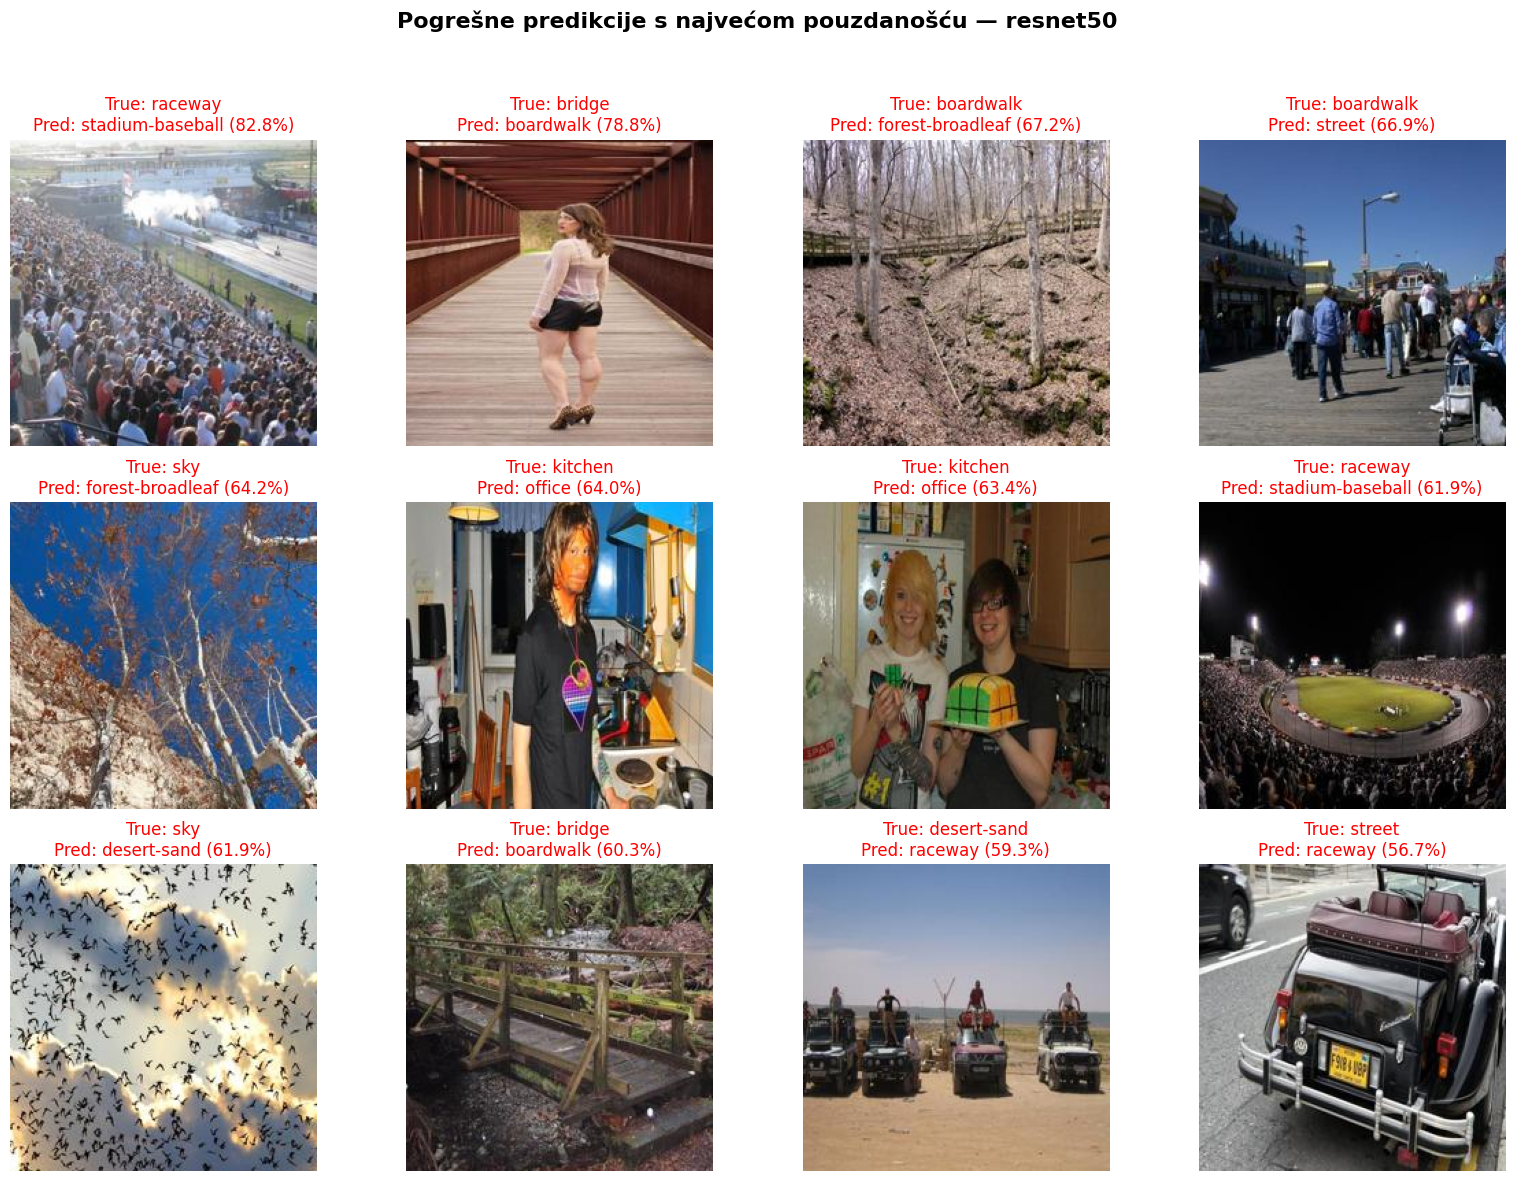

In [ ]:
def tensor_to_display_image(image_tensor):
    mean = torch.tensor(IMAGENET_MEAN).view(3, 1, 1)
    std = torch.tensor(IMAGENET_STD).view(3, 1, 1)
    image = image_tensor.cpu() * std + mean
    return image.permute(1, 2, 0).clamp(0, 1).numpy()

def plot_misclassification_gallery(model_name=None, n=12):
    if model_name is None:
        model_name = comparison_df.iloc[0]['model']

    cached = prediction_cache[model_name]
    wrong_positions = np.flatnonzero(
        cached['predictions'] != cached['labels']
    )

    if len(wrong_positions) == 0:
        print(f'No misclassifications found for {model_name}.')
        return

    ranked_positions = wrong_positions[
        np.argsort(-cached['confidences'][wrong_positions])
    ][:n]

    ncols = 4
    nrows = int(np.ceil(len(ranked_positions) / ncols))
    fig, axes = plt.subplots(
        nrows,
        ncols,
        figsize=(16, 4 * nrows),
        squeeze=False,
    )
    axes = axes.ravel()

    for ax, position in zip(axes, ranked_positions):
        sample_idx = int(cached['sample_indices'][position])
        image_tensor, _ = val_full_dataset[sample_idx]
        image = tensor_to_display_image(image_tensor)

        true_idx = int(cached['labels'][position])
        pred_idx = int(cached['predictions'][position])
        confidence = cached['confidences'][position]

        ax.imshow(image)
        ax.set_title(
            f'True: {class_names[true_idx]}\n'
            f'Pred: {class_names[pred_idx]} ({confidence:.1%})',
            color='red',
        )
        ax.axis('off')

    for ax in axes[len(ranked_positions):]:
        ax.axis('off')

    fig.suptitle(
        f'Pogrešne predikcije s najvećom pouzdanošću — {model_name}',
        fontsize=16,
        fontweight='bold',
        y=0.98,
    )

    plt.tight_layout(rect=[0, 0, 1, 0.95])

    plt.savefig(
        os.path.join(
            CONFIG['save_dir'],
            f'misclassification_gallery_{model_name}.png',
        ),
        dpi=200,
        bbox_inches='tight',
    )
    plt.show()

plot_misclassification_gallery()

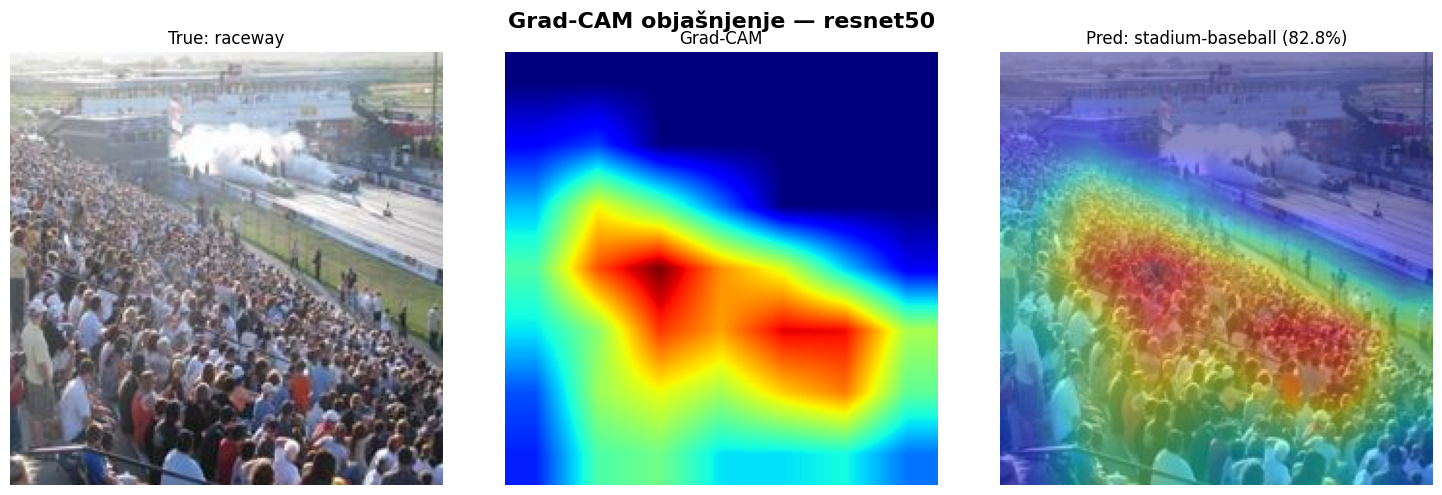

In [ ]:
import torch.nn.functional as F

def find_last_conv_layer(model):
    conv_layers = [
        module for module in model.modules()
        if isinstance(module, nn.Conv2d)
    ]
    if not conv_layers:
        raise ValueError('No convolutional layer found.')
    return conv_layers[-1]

def compute_gradcam(model, image_tensor, target_class=None):
    activations = {}
    gradients = {}
    target_layer = find_last_conv_layer(model)

    forward_handle = target_layer.register_forward_hook(
        lambda module, inputs, output: activations.update(value=output)
    )
    backward_handle = target_layer.register_full_backward_hook(
        lambda module, grad_input, grad_output: gradients.update(
            value=grad_output[0]
        )
    )

    model.eval()
    model.zero_grad(set_to_none=True)

    with torch.enable_grad():
        input_tensor = image_tensor.unsqueeze(0).to(device)
        input_tensor.requires_grad_(True)
        logits = model(input_tensor)

        probabilities = torch.softmax(logits, dim=1)
        if target_class is None:
            target_class = int(probabilities.argmax(dim=1).item())

        logits[0, target_class].backward()

        weights = gradients['value'].mean(dim=(2, 3), keepdim=True)
        cam = (weights * activations['value']).sum(dim=1).relu()
        cam = F.interpolate(
            cam.unsqueeze(1),
            size=image_tensor.shape[-2:],
            mode='bilinear',
            align_corners=False,
        ).squeeze()

        cam = cam.detach().cpu()
        cam = (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)

    forward_handle.remove()
    backward_handle.remove()

    predicted_class = int(probabilities.argmax(dim=1).item())
    confidence = float(probabilities[0, predicted_class].item())
    return cam.numpy(), predicted_class, confidence

def show_gradcam(model_name=None, sample_position=None):
    if model_name is None:
        model_name = comparison_df.iloc[0]['model']

    cached = prediction_cache[model_name]
    wrong_positions = np.flatnonzero(
        cached['predictions'] != cached['labels']
    )

    if sample_position is None:
        if len(wrong_positions) > 0:
            sample_position = wrong_positions[
                np.argmax(cached['confidences'][wrong_positions])
            ]
        else:
            sample_position = int(np.argmax(cached['confidences']))

    sample_idx = int(cached['sample_indices'][sample_position])
    image_tensor, _ = val_full_dataset[sample_idx]
    cam, pred_idx, confidence = compute_gradcam(
        models_to_eval[model_name],
        image_tensor,
    )
    image = tensor_to_display_image(image_tensor)
    heatmap = plt.get_cmap('jet')(cam)[..., :3]
    overlay = 0.55 * image + 0.45 * heatmap

    true_idx = int(cached['labels'][sample_position])
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    axes[0].imshow(image)
    axes[0].set_title(f'True: {class_names[true_idx]}')
    axes[1].imshow(cam, cmap='jet')
    axes[1].set_title('Grad-CAM')
    axes[2].imshow(overlay)
    axes[2].set_title(
        f'Pred: {class_names[pred_idx]} ({confidence:.1%})'
    )

    for ax in axes:
        ax.axis('off')

    fig.suptitle(
        f'Grad-CAM objašnjenje — {model_name}',
        fontsize=16,
        fontweight='bold',
    )
    plt.tight_layout()
    plt.savefig(
        os.path.join(CONFIG['save_dir'], f'gradcam_{model_name}.png'),
        dpi=200,
        bbox_inches='tight',
    )
    plt.show()

show_gradcam()

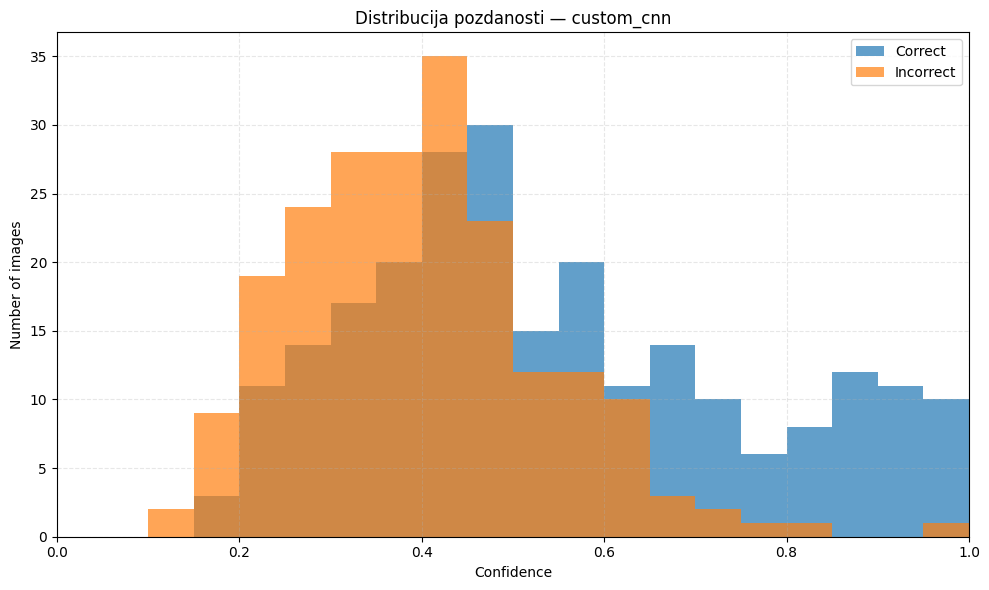

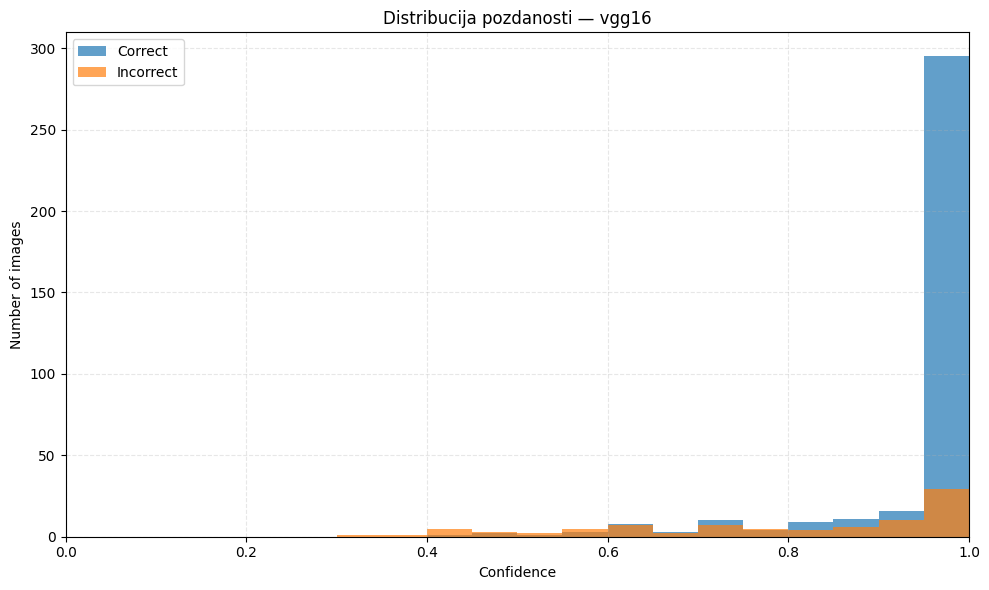

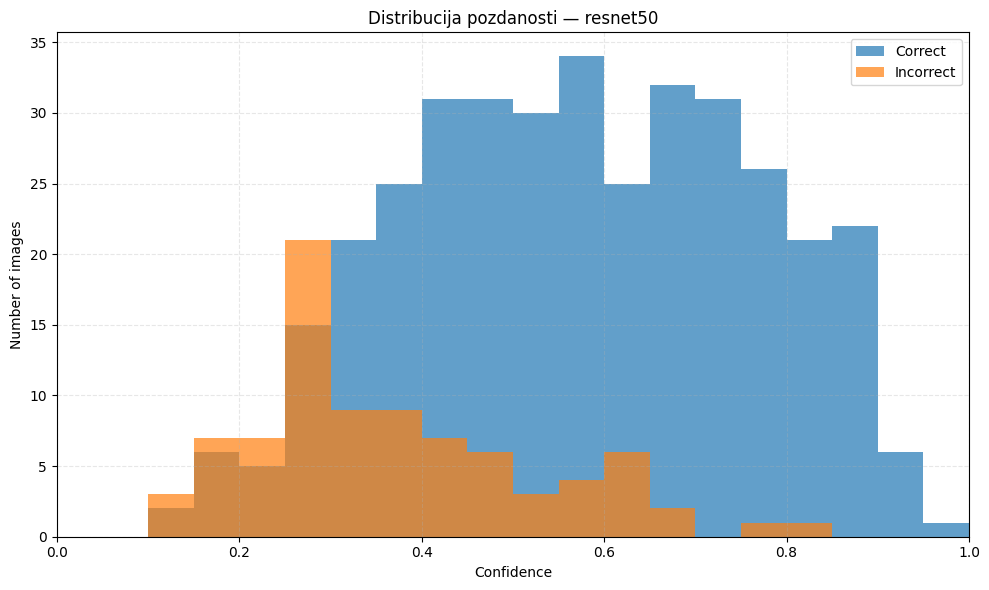

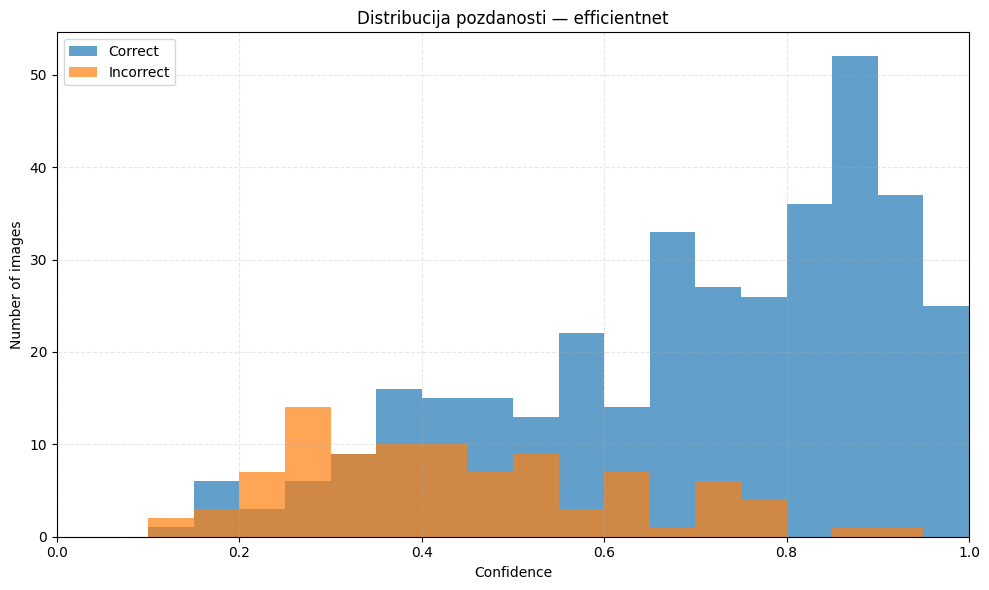

In [ ]:
model_order = [
    'custom_cnn',
    'vgg16',
    'resnet50',
    'efficientnet',
]

bins = np.linspace(0.0, 1.0, 21)

for model_name in model_order:
    cached = prediction_cache[model_name]
    correct = cached['predictions'] == cached['labels']
    incorrect = ~correct

    plt.figure(figsize=(10, 6))

    plt.hist(
        cached['confidences'][correct],
        bins=bins,
        alpha=0.7,
        color='tab:blue',
        label='Correct',
    )
    plt.hist(
        cached['confidences'][incorrect],
        bins=bins,
        alpha=0.7,
        color='tab:orange',
        label='Incorrect',
    )

    plt.xlabel('Confidence')
    plt.ylabel('Number of images')
    plt.title(f'Distribucija pozdanosti — {model_name}')
    plt.xlim(0, 1)
    plt.grid(alpha=0.3, linestyle='--')
    plt.legend()
    plt.tight_layout()

    plt.savefig(
        os.path.join(
            CONFIG['save_dir'],
            f'confidence_distribution_{model_name}.png',
        ),
        dpi=200,
        bbox_inches='tight',
    )
    plt.show()

,model,test_accuracy,parameters_m,trainable_parameters_m,model_size_mb,inference_ms_per_image
0,resnet50,0.808889,23.538767,0.030735,89.996311,2.639927
1,vgg16,0.806667,134.321999,119.607311,512.397762,4.411653
2,efficientnet,0.791111,4.026763,0.019215,15.521534,1.270790
3,custom_cnn,0.533333,0.423727,0.423727,1.620083,0.670995


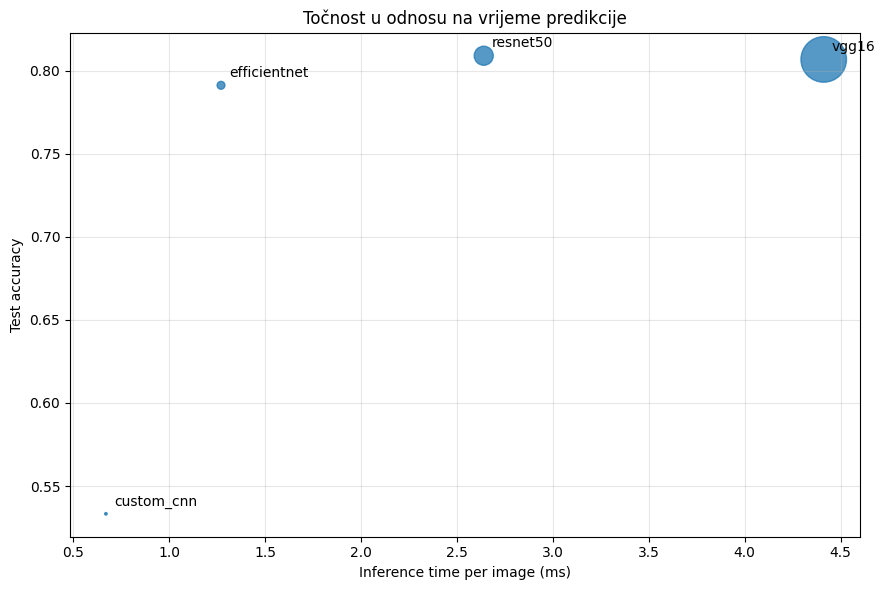

In [ ]:
import time

def count_parameters(model, trainable_only=False):
    parameters = model.parameters()
    if trainable_only:
        parameters = [p for p in parameters if p.requires_grad]
    return sum(p.numel() for p in parameters)

def model_size_mb(model):
    tensors = list(model.parameters()) + list(model.buffers())
    total_bytes = sum(t.numel() * t.element_size() for t in tensors)
    return total_bytes / (1024 ** 2)

@torch.inference_mode()
def benchmark_inference(model, loader, device, warmup=2, n_batches=10):
    model.eval()
    images, _ = next(iter(loader))
    images = images.to(device, non_blocking=True)

    for _ in range(warmup):
        _ = model(images)

    if device.type == 'cuda':
        torch.cuda.synchronize()

    start = time.perf_counter()
    batches_measured = 0

    for _ in range(n_batches):
        _ = model(images)
        batches_measured += 1

    if device.type == 'cuda':
        torch.cuda.synchronize()

    elapsed = time.perf_counter() - start
    total_images = batches_measured * images.size(0)
    return 1000 * elapsed / total_images

efficiency_rows = []
for name, model in models_to_eval.items():
    efficiency_rows.append({
        'model': name,
        'test_accuracy': results[name]['accuracy'],
        'parameters_m': count_parameters(model) / 1e6,
        'trainable_parameters_m': count_parameters(
            model,
            trainable_only=True,
        ) / 1e6,
        'model_size_mb': model_size_mb(model),
        'inference_ms_per_image': benchmark_inference(
            model,
            test_loader,
            device,
        ),
    })

efficiency_df = (
    pd.DataFrame(efficiency_rows)
    .sort_values('test_accuracy', ascending=False)
    .reset_index(drop=True)
)

display(efficiency_df)

fig, ax = plt.subplots(figsize=(9, 6))
scatter = ax.scatter(
    efficiency_df['inference_ms_per_image'],
    efficiency_df['test_accuracy'],
    s=efficiency_df['parameters_m'] * 8,
    alpha=0.75,
)

for _, row in efficiency_df.iterrows():
    ax.annotate(
        row['model'],
        (
            row['inference_ms_per_image'],
            row['test_accuracy'],
        ),
        xytext=(6, 6),
        textcoords='offset points',
    )

ax.set_xlabel('Inference time per image (ms)')
ax.set_ylabel('Test accuracy')
ax.set_title('Točnost u odnosu na vrijeme predikcije')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(
    os.path.join(CONFIG['save_dir'], 'model_efficiency.png'),
    dpi=200,
    bbox_inches='tight',
)
plt.show()